# Single-cell RNA-seq Data Preprocessing

This notebook covers the reading of single-cell data, extraction of specific cell subpopulations, filtering of lowly expressed genes, highly variable gene (HVG) selection, as well as data normalization and log transformation.

In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# Ignore warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data and Extract Erythroid Cells
If the metadata provides annotation information for cell stages, it can be used directly. Otherwise, the cells need to be classified into different stages through pseudo-time clustering.

In [12]:
df_raw_count = pd.read_csv('2023-matrix.csv', index_col=0)
df_meta = pd.read_csv('2023-clusters.csv',index_col=0)
print("Raw count data:\n{}".format(df_raw_count.head(5)))
print("Cell annotation information:\n{}".format(df_meta.head(5)))
# Read erythroid cells from different developmental stages
df_early = pd.read_csv('Ery_early_expression0.csv', index_col=0)
df_mid = pd.read_csv('Ery_mid_expression1.csv', index_col=0)
df_late = pd.read_csv('Ery_late_expression2.csv', index_col=0)
#print(df_early.head(5))
# Merge cell name lists
hEry_cell = list(df_early.columns) + list(df_mid.columns) + list(df_late.columns)

# Extract these cells from the total matrix
df_raw_count = df_raw_count[hEry_cell]

print("Dimension of the extracted erythroid cell expression matrix:", df_raw_count.shape)
df_raw_count.head(5)

Raw count data:
             AAACCCAAGAACCGCA.1_VEGFA  AAACCCACACTAAACC.1_VEGFA  \
MIR1302-2HG                         0                         0   
FAM138A                             0                         0   
OR4F5                               0                         0   
AL627309.1                          0                         0   
AL627309.3                          0                         0   

             AAACCCACACTGATTG.1_VEGFA  AAACCCACAGACAATA.1_VEGFA  \
MIR1302-2HG                         0                         0   
FAM138A                             0                         0   
OR4F5                               0                         0   
AL627309.1                          0                         0   
AL627309.3                          0                         0   

             AAACCCACAGCTTCCT.1_VEGFA  AAACCCACAGGACATG.1_VEGFA  \
MIR1302-2HG                         0                         0   
FAM138A                             0       

,AAACCCACACTGATTG.1_VEGFA,AAACCCAGTCGGTACC.1_VEGFA,AAACGAAAGGTTGGAC.1_VEGFA,AAACGCTCACTTGGGC.1_VEGFA,AAACGCTCATCCGTTC.1_VEGFA,AAAGTGATCCTCGATC.1_VEGFA,AACAAAGCAGCCGTCA.1_VEGFA,AACAAAGTCAGACCGC.1_VEGFA,AACCAACTCTCGGGAC.1_VEGFA,AACCATGGTATAGGGC.1_VEGFA,...,TTTCAGTTCACCTCGT.1_VEGFAC,TTTCATGAGTAATACG.1_VEGFAC,TTTCGATCAGCATGCC.1_VEGFAC,TTTCGATCATCCGGCA.1_VEGFAC,TTTCGATCATTGGGAG.1_VEGFAC,TTTGACTGTAACGGTG.1_VEGFAC,TTTGGAGCACATAGCT.1_VEGFAC,TTTGGAGCAGGCTCTG.1_VEGFAC,TTTGGTTTCGTTACCC.1_VEGFAC,TTTGTTGAGTCCTGCG.1_VEGFAC
MIR1302-2HG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FAM138A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
OR4F5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AL627309.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AL627309.3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Gene Filtering: Remove Lowly Expressed Genes
Filter out genes expressed in fewer than 10 cells.

In [7]:
# Calculate the number of non-zero values per row (gene)
non_zero_counts = (df_raw_count != 0).astype(int).sum(axis=1)

# Filter out rows with non-zero values >= 10
filtered_df = df_raw_count[non_zero_counts >= 10]

print("Dimension of the filtered expression matrix:", filtered_df.shape)
filtered_df.head(10)

Dimension of the filtered expression matrix: (17319, 4651)


,AAACCCACACTGATTG.1_VEGFA,AAACCCAGTCGGTACC.1_VEGFA,AAACGAAAGGTTGGAC.1_VEGFA,AAACGCTCACTTGGGC.1_VEGFA,AAACGCTCATCCGTTC.1_VEGFA,AAAGTGATCCTCGATC.1_VEGFA,AACAAAGCAGCCGTCA.1_VEGFA,AACAAAGTCAGACCGC.1_VEGFA,AACCAACTCTCGGGAC.1_VEGFA,AACCATGGTATAGGGC.1_VEGFA,...,TTTCAGTTCACCTCGT.1_VEGFAC,TTTCATGAGTAATACG.1_VEGFAC,TTTCGATCAGCATGCC.1_VEGFAC,TTTCGATCATCCGGCA.1_VEGFAC,TTTCGATCATTGGGAG.1_VEGFAC,TTTGACTGTAACGGTG.1_VEGFAC,TTTGGAGCACATAGCT.1_VEGFAC,TTTGGAGCAGGCTCTG.1_VEGFAC,TTTGGTTTCGTTACCC.1_VEGFAC,TTTGTTGAGTCCTGCG.1_VEGFAC
AL627309.5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AP006222.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
LINC01409,0,0,0,1,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
LINC01128,0,1,1,0,0,0,1,2,1,0,...,0,1,1,0,0,0,1,3,3,1
LINC00115,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FAM41C,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAMD11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NOC2L,0,2,4,1,1,2,1,0,0,4,...,0,1,1,1,0,2,0,0,2,0
KLHL17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HES4,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,4,0,0,0


## 3. Construct AnnData Object and Highly Variable Gene (HVG) Selection
**Note:** `flavor='seurat_v3'` requires unnormalized raw counts. Therefore, HVG selection is performed before normalization and log1p transformation.

Initialized adata object:
 AnnData object with n_obs × n_vars = 4651 × 17319


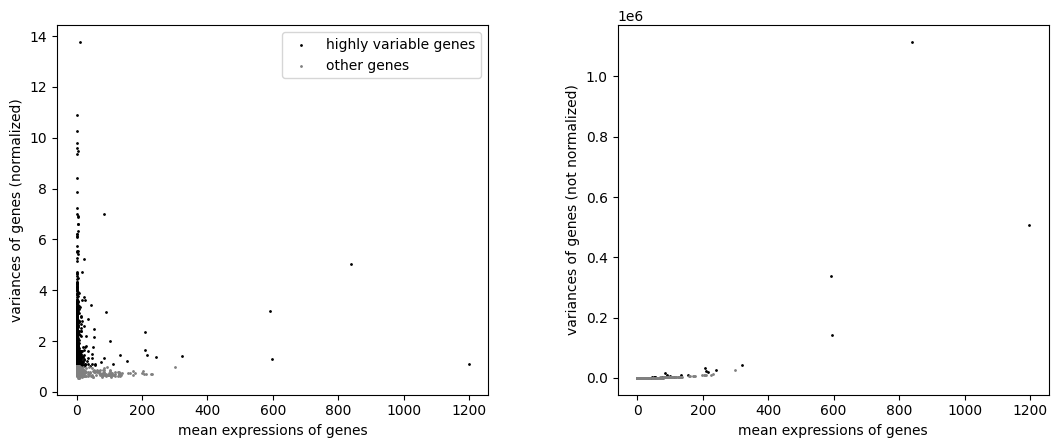

In [8]:
# Scanpy expects cells in rows and genes in columns, so transpose the matrix (.T)
adata = sc.AnnData(filtered_df.T)
print("Initialized adata object:\n", adata)

# Select highly variable genes (Seurat v3 requires raw counts)
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=5000)

# Plot highly variable genes
sc.pl.highly_variable_genes(adata)

## 4. Data Normalization and Log Transformation

In [9]:
# Save the raw counts in adata.raw for potential downstream differential analysis
adata.raw = adata

# Perform library size normalization
sc.pp.normalize_total(adata, target_sum=1e4)

# Perform log transformation
sc.pp.log1p(adata)

# ------------------------- Get Log-transformed Expression Data -----------------------------
log_expression_data = adata.X
genes = adata.var_names
cells = adata.obs_names

# Create a DataFrame
log_expression_df = pd.DataFrame(log_expression_data.T, index=genes, columns=cells)
print("Dimension of log-normalized expression data:", log_expression_df.shape)

# Optional: Save the DataFrame as a CSV file
# log_expression_df.to_csv('log_normalization_exp_data.csv')

log_expression_df.head(10)

Dimension of log-normalized expression data: (17319, 4651)


,AAACCCACACTGATTG.1_VEGFA,AAACCCAGTCGGTACC.1_VEGFA,AAACGAAAGGTTGGAC.1_VEGFA,AAACGCTCACTTGGGC.1_VEGFA,AAACGCTCATCCGTTC.1_VEGFA,AAAGTGATCCTCGATC.1_VEGFA,AACAAAGCAGCCGTCA.1_VEGFA,AACAAAGTCAGACCGC.1_VEGFA,AACCAACTCTCGGGAC.1_VEGFA,AACCATGGTATAGGGC.1_VEGFA,...,TTTCAGTTCACCTCGT.1_VEGFAC,TTTCATGAGTAATACG.1_VEGFAC,TTTCGATCAGCATGCC.1_VEGFAC,TTTCGATCATCCGGCA.1_VEGFAC,TTTCGATCATTGGGAG.1_VEGFAC,TTTGACTGTAACGGTG.1_VEGFAC,TTTGGAGCACATAGCT.1_VEGFAC,TTTGGAGCAGGCTCTG.1_VEGFAC,TTTGGTTTCGTTACCC.1_VEGFAC,TTTGTTGAGTCCTGCG.1_VEGFAC
AL627309.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
AP006222.2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
LINC01409,0.000000,0.000000,0.000000,0.224583,0.000000,0.000000,0.214116,0.000000,0.000000,0.000000,...,0.0,0.000000,0.00000,0.372322,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
LINC01128,0.000000,0.318052,0.222307,0.000000,0.000000,0.000000,0.214116,0.346927,0.282752,0.000000,...,0.0,0.321726,0.19904,0.000000,0.0,0.000000,0.334563,0.819355,0.953318,0.652218
LINC00115,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
FAM41C,0.196982,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
SAMD11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
NOC2L,0.000000,0.558984,0.691054,0.224583,0.417376,0.847946,0.214116,0.000000,0.000000,0.588606,...,0.0,0.321726,0.19904,0.372322,0.0,0.370661,0.000000,0.000000,0.724098,0.000000
KLHL17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
HES4,0.000000,0.318052,0.000000,0.000000,0.417376,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.00000,0.000000,0.0,0.000000,0.951395,0.000000,0.000000,0.000000


## 5. Format and Export Highly Variable Genes Table

In [10]:
# Get boolean mask for highly variable genes
highly_variable_mask = adata.var['highly_variable']

# Extract names of highly variable genes
top_5000_hvg = adata.var_names[highly_variable_mask]

# Extract corresponding variances
variance = adata.var['variances'][highly_variable_mask]

# Create DataFrame and sort descending by variance
highly_variable_genes_df = pd.DataFrame({'gene': top_5000_hvg, 'variance': variance})
highly_variable_genes_df = highly_variable_genes_df.sort_values(by='variance', ascending=False).reset_index(drop=True)

# Filter out some unknown genes
df_filtered = highly_variable_genes_df[highly_variable_genes_df['gene'].str.len() <= 7]

print("Final filtered highly variable genes (sorted by variance):")
print(df_filtered)

# Optional: Export results
# df_filtered.to_csv('hvg_genes_seurat.csv', index=False)

Final filtered highly variable genes (sorted by variance):
         gene      variance
0         HBZ  1.114151e+06
1        HBG2  5.064434e+05
2      MALAT1  3.383405e+05
3        HBG1  1.418483e+05
4      MT-CO2  4.389776e+04
...       ...           ...
4989    TRPM2  2.790104e-03
4990  ANKRD35  2.790104e-03
4991    FHOD3  2.790104e-03
4994    KCNQ1  2.790104e-03
4997   CHST15  2.790104e-03

[4060 rows x 2 columns]
